# Relacion entre ocupacion y educacion

In [1]:

from pathlib import Path
import pandas as pd

ruta_dataset = Path("..") / "data" / "online food delivery dataset.csv"
df = pd.read_csv(ruta_dataset)

# El archivo termina con una coma, por lo que pandas crea una columna vacia.
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]

In [2]:
df.columns

Index(['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income',
       'Educational Qualifications', 'Family size', 'Customer Type',
       'latitude', 'longitude', 'Pin code', 'Output', 'Feedback'],
      dtype='str')

In [4]:
print(df["Educational Qualifications"].value_counts())

print(df["Occupation"].value_counts())

Educational Qualifications
Graduate         177
Post Graduate    174
Ph.D              23
School            12
Uneducated         2
Name: count, dtype: int64
Occupation
Student           207
Employee          118
Self Employeed     54
House wife          9
Name: count, dtype: int64


In [5]:
tabla_educacion_ocupacion = pd.crosstab(
    df["Educational Qualifications"],
    df["Occupation"]
)

print("Frecuencias:")
display(tabla_educacion_ocupacion)

print("Ocupación más frecuente dentro de cada nivel educativo:")
display(tabla_educacion_ocupacion.idxmax(axis=1).to_frame("ocupacion_mas_frecuente"))

Frecuencias:


Occupation,Employee,House wife,Self Employeed,Student
Educational Qualifications,,,,
Graduate,68,3,29,77
Ph.D,12,0,3,8
Post Graduate,38,0,14,122
School,0,5,7,0
Uneducated,0,1,1,0


Ocupación más frecuente dentro de cada nivel educativo:


,ocupacion_mas_frecuente
Educational Qualifications,
Graduate,Student
Ph.D,Employee
Post Graduate,Student
School,Self Employeed
Uneducated,House wife


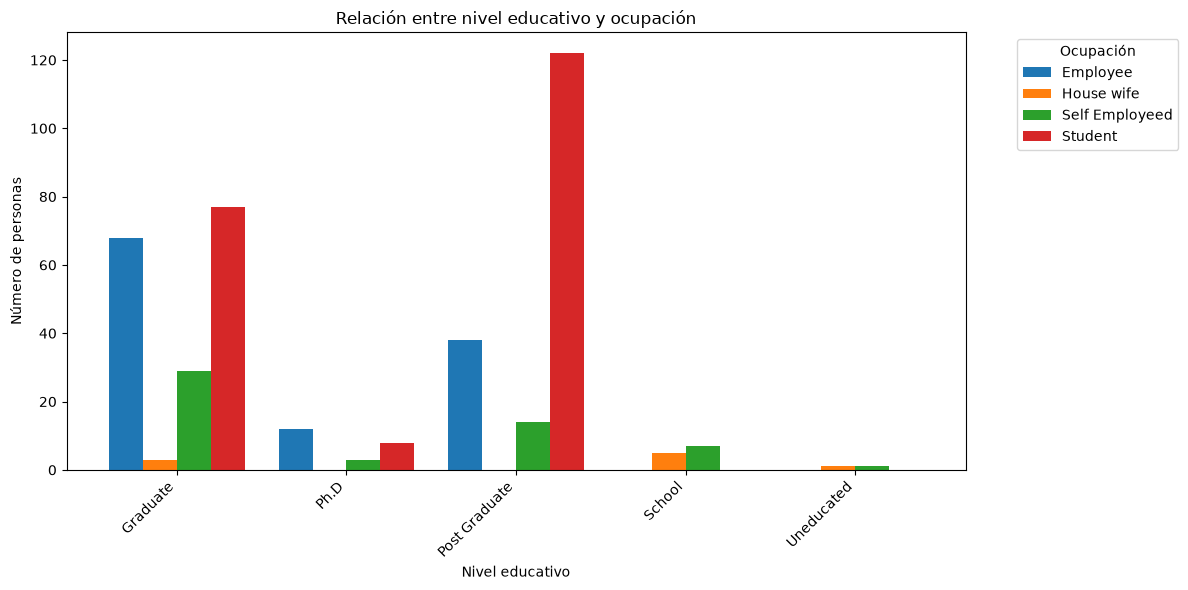

In [6]:
import matplotlib.pyplot as plt

tabla_educacion_ocupacion.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

plt.title("Relación entre nivel educativo y ocupación")
plt.xlabel("Nivel educativo")
plt.ylabel("Número de personas")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Ocupación", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

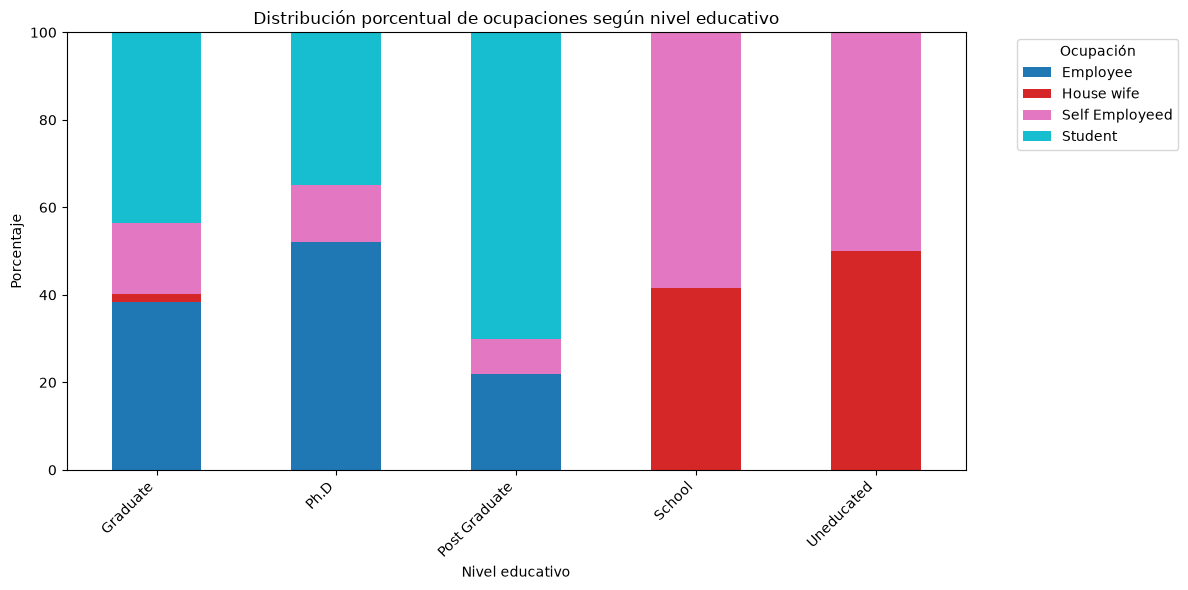

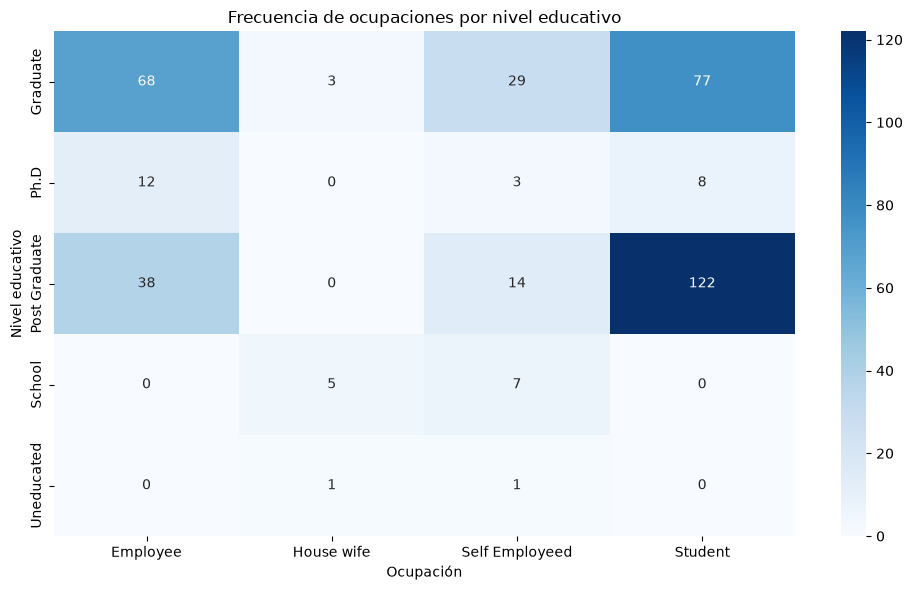

Chi-cuadrado: 165.653
Valor p: 0.0000
Existe una relación estadísticamente significativa entre educación y ocupación.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Porcentajes dentro de cada nivel educativo
tabla_porcentajes = pd.crosstab(
    df["Educational Qualifications"],
    df["Occupation"],
    normalize="index"
).mul(100)

# Barras apiladas porcentuales
tabla_porcentajes.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="tab10"
)

plt.title("Distribución porcentual de ocupaciones según nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Porcentaje")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Ocupación", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Mapa de calor de frecuencias
plt.figure(figsize=(10, 6))
sns.heatmap(
    tabla_educacion_ocupacion,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Frecuencia de ocupaciones por nivel educativo")
plt.xlabel("Ocupación")
plt.ylabel("Nivel educativo")
plt.tight_layout()
plt.show()

# Prueba chi-cuadrado
chi2, p_valor, grados_libertad, frecuencias_esperadas = chi2_contingency(
    tabla_educacion_ocupacion
)

print(f"Chi-cuadrado: {chi2:.3f}")
print(f"Valor p: {p_valor:.4f}")

if p_valor < 0.05:
    print("Existe una relación estadísticamente significativa entre educación y ocupación.")
else:
    print("No se observa una relación estadísticamente significativa.")

    

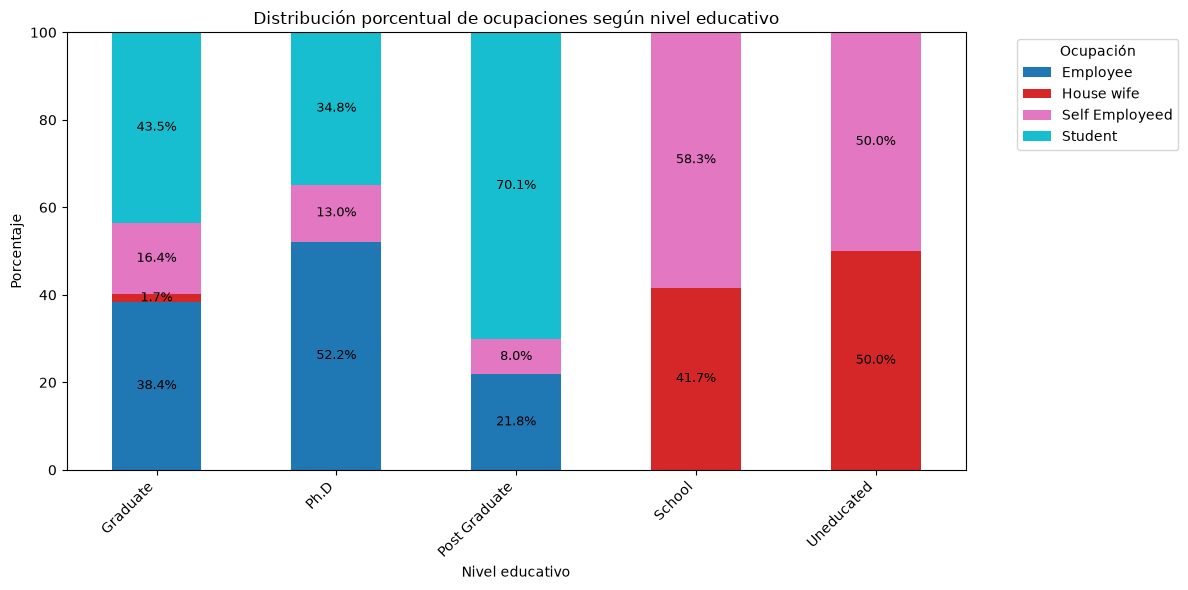

In [8]:
# Barras apiladas porcentuales con etiquetas
ax = tabla_porcentajes.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="tab10"
)

for indice, nivel_educativo in enumerate(tabla_porcentajes.index):
    acumulado = 0

    for ocupacion in tabla_porcentajes.columns:
        porcentaje = tabla_porcentajes.loc[nivel_educativo, ocupacion]

        if porcentaje > 0:
            ax.text(
                indice,
                acumulado + porcentaje / 2,
                f"{porcentaje:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )

        acumulado += porcentaje

plt.title("Distribución porcentual de ocupaciones según nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Porcentaje")
plt.xticks(rotation=45, ha="right")
plt.legend(
    title="Ocupación",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()